# Evaluator and Optimizer

In [1]:
# import your LLM model
from langchain_ollama import ChatOllama
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image,display,Markdown
from typing_extensions import Literal
from pydantic import BaseModel,Field
from langchain_core.messages import HumanMessage,SystemMessage
llm = ChatOllama(model='llama3.1:8b')
results = llm.invoke('Hello my name is Hanif')
print(results)

content='Nice to meet you, Hanif! Is there something I can help you with or would you like to chat for a bit?' additional_kwargs={} response_metadata={'model': 'llama3.1:8b', 'created_at': '2025-11-30T09:26:27.2294477Z', 'done': True, 'done_reason': 'stop', 'total_duration': 10503898900, 'load_duration': 7844531900, 'prompt_eval_count': 16, 'prompt_eval_duration': 747188300, 'eval_count': 27, 'eval_duration': 1903174100, 'model_name': 'llama3.1:8b'} id='run--f2d9e8e6-2361-4bc1-ac2c-04c12f8311cb-0' usage_metadata={'input_tokens': 16, 'output_tokens': 27, 'total_tokens': 43}


In [2]:
class State(TypedDict):
    joke : str
    topic : str
    feedback : str
    funny_or_not : str

In [24]:
class Feedback(BaseModel):
    grade : Literal["funny", "not funny"] = Field(description = 'Decide if joke is funny or not funny')
    feedback : str = Field(description='if the joke is not funny please give the feedback to improve it')

evaluator = llm.with_structured_output(Feedback)

In [25]:
# Nodes
def llm_call_generator (state : State):
    """LLM generate a joke"""

    if state.get("feedback"):
        msg = llm.invoke([
            f"Write a joke about {state['topic']}. Here is some feedback to improve the joke: {state['feedback']}"])
    else:
        msg = llm.invoke([f"Write a joke about {state['topic']}"])
    return {"joke":msg.content}

def llm_call_evaluator(state : State):
    """LLM evaluates the joke"""

    grade = evaluator.invoke([f"Grade the joke {state['joke']}"])
    return {"funny_or_not":grade.grade,"feedback":grade.feedback}

def route_joke(state: State):
    """Route the joke based on its funniness"""
    if state['funny_or_not'] == 'funny':
        return "Accepted"
    elif state['funny_or_not'] == 'not funny':
        return 'Rejected + Feedback'

In [26]:
# Build the workflow graph

evaluator_optimizer_graph = StateGraph(State)

evaluator_optimizer_graph.add_node("llm_call_generator", llm_call_generator)
evaluator_optimizer_graph.add_node("llm_call_evaluator", llm_call_evaluator)

evaluator_optimizer_graph.add_edge(START, "llm_call_generator")
evaluator_optimizer_graph.add_edge("llm_call_generator", "llm_call_evaluator")
evaluator_optimizer_graph.add_conditional_edges(
    "llm_call_evaluator",
    route_joke,
    {
        "Accepted": END,
        "Rejected + Feedback": "llm_call_generator"
    }   
)

evaluator_optimizer_workflow = evaluator_optimizer_graph.compile()

In [19]:
mermaid_code = evaluator_optimizer_workflow.get_graph().draw_mermaid()
with open("evaluator_optimizer_workflow.mmd", "w") as f:
    f.write(mermaid_code)


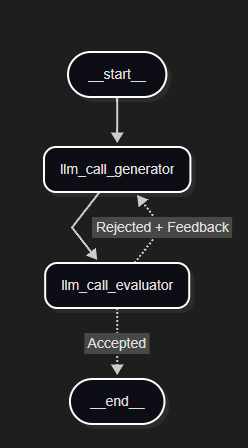

In [27]:
config = {'configurable': {'thread_id': '2'}}
state={"topic":"early married life challenges"}
for chunk in evaluator_optimizer_workflow.stream(state,config,stream_mode='updates'):
    print(chunk)

{'llm_call_generator': {'joke': "Why did the newlywed couple bring a ladder to their therapist's office?\n\nBecause they wanted to take their relationship to the next level, but it was clear they were struggling with the small stuff – like whose turn it is to do laundry."}}
{'llm_call_evaluator': {'funny_or_not': 'funny', 'feedback': "It's a play on words that creates humor. It takes a common phrase 'take their relationship to the next level' which is typically associated with romantic relationships, and adds an unexpected twist by bringing a ladder into it."}}


In [30]:
response  = evaluator_optimizer_workflow.invoke({"topic":"early married life challenges"})
print(response)

{'joke': 'Here\'s one:\n\n"Why did the newlywed couple bring a ladder to their first argument?"\n\n(wait for it...)\n\n"Because they wanted to take their relationship to the next level... but it kept getting stuck on who left the dishes in the sink!"', 'topic': 'early married life challenges', 'feedback': 'clever play on words and unexpected twist at the end. The setup is relatable, and the punchline is a clever wordplay that ties back to the idea of taking their relationship to the next level, but also subverts expectations with the mundane issue of household chores.', 'funny_or_not': 'funny'}
